# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

### Instrucciones Generales:
1. **Validación:** No entrenes y midas sobre el mismo conjunto (sobreajuste). Recuerda haber dividido en Entrenamiento y Prueba antes.
2. **Entrenamiento Base:** Entrena los siguientes modelos base con tu set de Entrenamiento y compáralos usando RMSE (Error Cuadrático Medio):
   - `LinearRegression`
   - `SGDRegressor`
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`
3. **Cross Validation (Validación Cruzada):** Para tener una métrica robusta, usa `cross_val_score` en el set de Entrenamiento para cada uno de los modelos anteriores.
4. **Ajuste Fino (Fine Tuning):** Toma el modelo ganador y busca sus mejores hiperparámetros. Utiliza un `GridSearchCV` explorando el número de estimadores (`n_estimators`), las características máximas (`max_features`), etc.
5. **Conclusión y Benchmark (IMPORTANTE):** Redacta una conclusión comparando los algoritmos. Explica por qué escogiste el modelo final y valida tu decisión calculando el RMSE sobre tu Set de Prueba que habías reservado. Documenta si alguno de tus modelos se sobreajusto o subajusto. Recuerda que el modelo final no puede tener esos problemas!


# 1. Validación

In [1]:
import pandas as pd

TARGET = "median_house_value"
train = pd.read_csv("../data/processed/train_set.csv")
test = pd.read_csv("../data/processed/test_set.csv")

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16512, 15) (16512,)
(4089, 15) (4089,)


# 2. Entrenamiento Base

In [2]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   16512 non-null  float64
 1   latitude                    16512 non-null  float64
 2   housing_median_age          16512 non-null  float64
 3   total_rooms                 16512 non-null  float64
 4   total_bedrooms              16512 non-null  float64
 5   population                  16512 non-null  float64
 6   households                  16512 non-null  float64
 7   median_income               16512 non-null  float64
 8   rooms_per_household         16512 non-null  float64
 9   population_per_household    16512 non-null  float64
 10  bedrooms_per_room           16512 non-null  float64
 11  ocean_proximity_INLAND      16512 non-null  int64  
 12  ocean_proximity_ISLAND      16512 non-null  int64  
 13  ocean_proximity_NEAR BAY    165

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import numpy as np

log_cols = ['total_bedrooms', 'total_rooms', 'households', 'population']

onehot_cols = [
    "ocean_proximity_INLAND",
    "ocean_proximity_ISLAND",
    "ocean_proximity_NEAR BAY",
    "ocean_proximity_NEAR OCEAN",
]

num_cols = [c for c in X_train.columns if c not in onehot_cols and c not in log_cols]

log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_transformer, log_cols),
        ("num", StandardScaler(), num_cols),
        ("onehot", "passthrough", onehot_cols),
    ],
    remainder="drop"
)

models = {
    "LinearRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    
    "SGDRegressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SGDRegressor(random_state=42))
    ]),

    "MLPRegressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", MLPRegressor(
                hidden_layer_sizes=(100, 50, 20), 
                learning_rate_init=0.001,
                alpha=1e-5,
                validation_fraction=0.2,
                max_iter=1000, 
                early_stopping=True,
                random_state=42, 
                ))
    ]),
    
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    
    "RandomForestRegressor": RandomForestRegressor(random_state=42, n_jobs=-1)
}

# 3. Cross Validation

In [4]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

def rmse_cv(model, X, y, cv=10, random_state=42):
    kfold = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=kfold,
        n_jobs=-1
    )
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean(), rmse_scores.std()

In [5]:
results = []

for name, model in models.items():
    print(f"Evaluando {name}...")
    mean_rmse, std_rmse = rmse_cv(model, X_train, y_train)
    result = {
        "Modelo": name,
        "RMSE_CV_Medio": mean_rmse,
        "RMSE_CV_Std": std_rmse
    }
    print(f'Resultados: RMSE CV Medio = {mean_rmse:.4f}, RMSE CV Std = {std_rmse:.4f}\n')
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="RMSE_CV_Medio")
results_df

Evaluando LinearRegression...
Resultados: RMSE CV Medio = 66477.6777, RMSE CV Std = 2160.2935

Evaluando SGDRegressor...
Resultados: RMSE CV Medio = 14219399.3610, RMSE CV Std = 40915405.7708

Evaluando MLPRegressor...
Resultados: RMSE CV Medio = 55691.1871, RMSE CV Std = 3986.0706

Evaluando DecisionTreeRegressor...
Resultados: RMSE CV Medio = 70191.0228, RMSE CV Std = 2873.5148

Evaluando RandomForestRegressor...
Resultados: RMSE CV Medio = 49660.2653, RMSE CV Std = 3117.8260



,Modelo,RMSE_CV_Medio,RMSE_CV_Std
4,RandomForestRegressor,4.966027e+04,3.117826e+03
2,MLPRegressor,5.569119e+04,3.986071e+03
0,LinearRegression,6.647768e+04,2.160294e+03
3,DecisionTreeRegressor,7.019102e+04,2.873515e+03
1,SGDRegressor,1.421940e+07,4.091541e+07


El mejor modelo es `RandomForestRegressor` por lo que lo escogemos para hacer fine tuning.

# 4. Ajuste Fino

In [6]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [3, 10, 30, 50, 100, 200, 300],
    "max_features": [2, 4, 6, 8, 10, "sqrt"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

best_rmse_cv = np.sqrt(-grid_search.best_score_)
print(f"RMSE CV del mejor modelo: {best_rmse_cv:.4f}")

Mejores hiperparámetros:
{'max_features': 6, 'n_estimators': 200}
RMSE CV del mejor modelo: 48770.8386


In [7]:
# Segundo fine tuning con valores más cercanos al óptimo encontrado

rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=6)

param_grid = {
    "n_estimators": [190, 195, 200, 205, 210]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

best_rmse_cv = np.sqrt(-grid_search.best_score_)
print(f"RMSE CV del mejor modelo: {best_rmse_cv:.4f}")

Mejores hiperparámetros:
{'n_estimators': 205}
RMSE CV del mejor modelo: 48766.8452


In [8]:
from sklearn.metrics import mean_squared_error

best_model = grid_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"RMSE Train: {train_rmse:.4f}")
print(f"RMSE Test:  {test_rmse:.4f}")

RMSE Train: 17839.5093
RMSE Test:  49112.5197


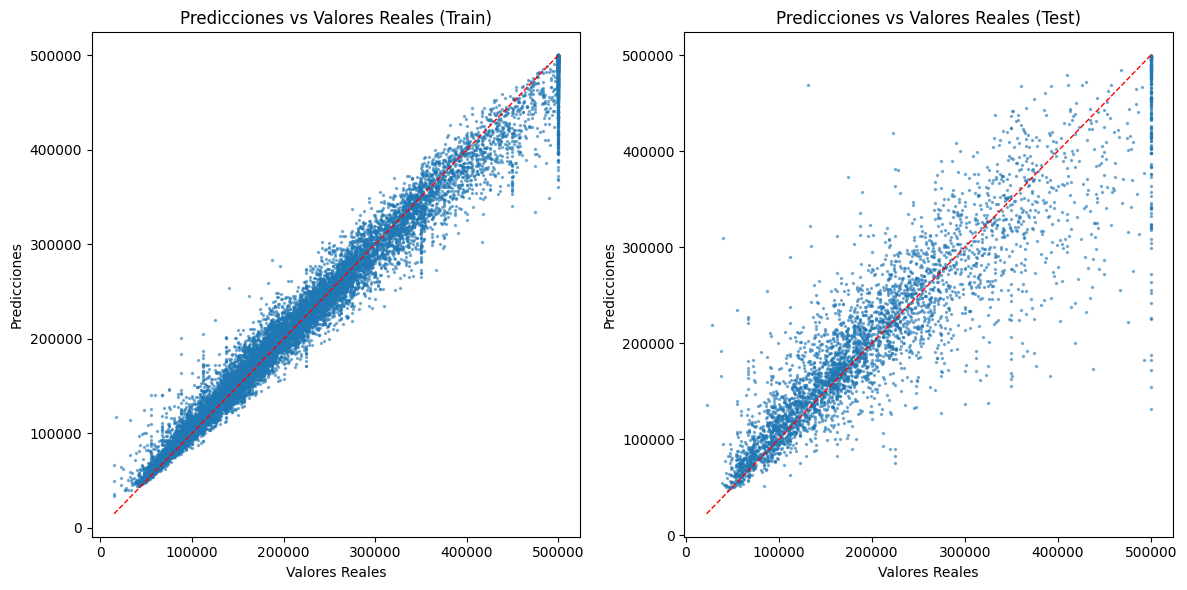

In [9]:
# Graficamos las predicciones vs los valores reales
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha=0.5, s=2)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Train)")
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5, s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Test)")
plt.tight_layout()
plt.show()

In [10]:
# Probamos modelo en casos con target menor al extremo superior de acuerdo con lo observado en la exploración (500,001 es el tope)

test_subset = test[test[TARGET] < 500001]

X_test_subset = test_subset.drop(columns=[TARGET])
y_test_subset = test_subset[TARGET]

test_subset_pred = best_model.predict(X_test_subset)
test_subset_rmse = np.sqrt(mean_squared_error(y_test_subset, test_subset_pred))

print(f"RMSE Test Subset (target < 500,001): {test_subset_rmse:.4f}")

RMSE Test Subset (target < 500,001): 45028.5533


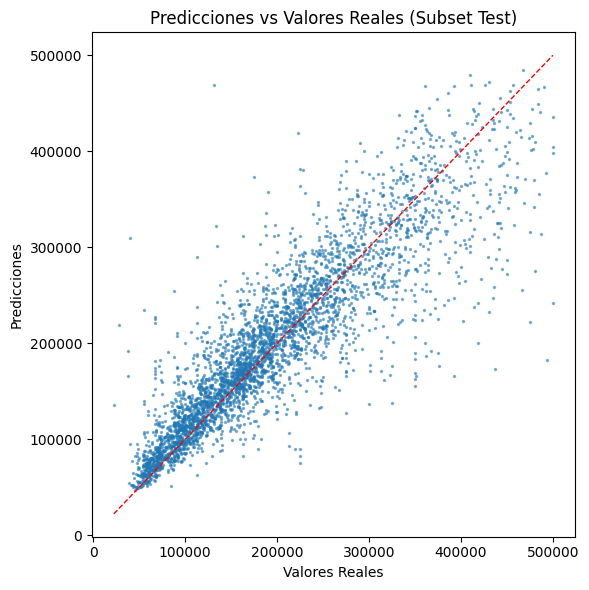

In [11]:
# Gráfico de predicciones vs valores reales para el subset
plt.figure(figsize=(6, 6))
plt.scatter(y_test_subset, test_subset_pred, alpha=0.5, s=2)
plt.plot([y_test_subset.min(), y_test_subset.max()], [y_test_subset.min(), y_test_subset.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Subset Test)")
plt.tight_layout()
plt.show()

In [12]:
# de nuevo sin límites de variables identificadas en exploración

from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=6)

param_grid = {
    "n_estimators": [200, 205, 210, 215]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

mask = (X_train["housing_median_age"] < 52) & (X_train["median_income"] < 15.0001) & (y_train < 500001)
grid_search.fit(X_train[mask], y_train[mask])

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

best_rmse_cv = np.sqrt(-grid_search.best_score_)
print(f"RMSE CV del mejor modelo: {best_rmse_cv:.4f}")

Mejores hiperparámetros:
{'n_estimators': 210}
RMSE CV del mejor modelo: 44356.5376


In [13]:
from sklearn.metrics import mean_squared_error

best_model = grid_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"RMSE Train: {train_rmse:.4f}")
print(f"RMSE Test:  {test_rmse:.4f}")

RMSE Train: 35889.1540
RMSE Test:  53060.1219


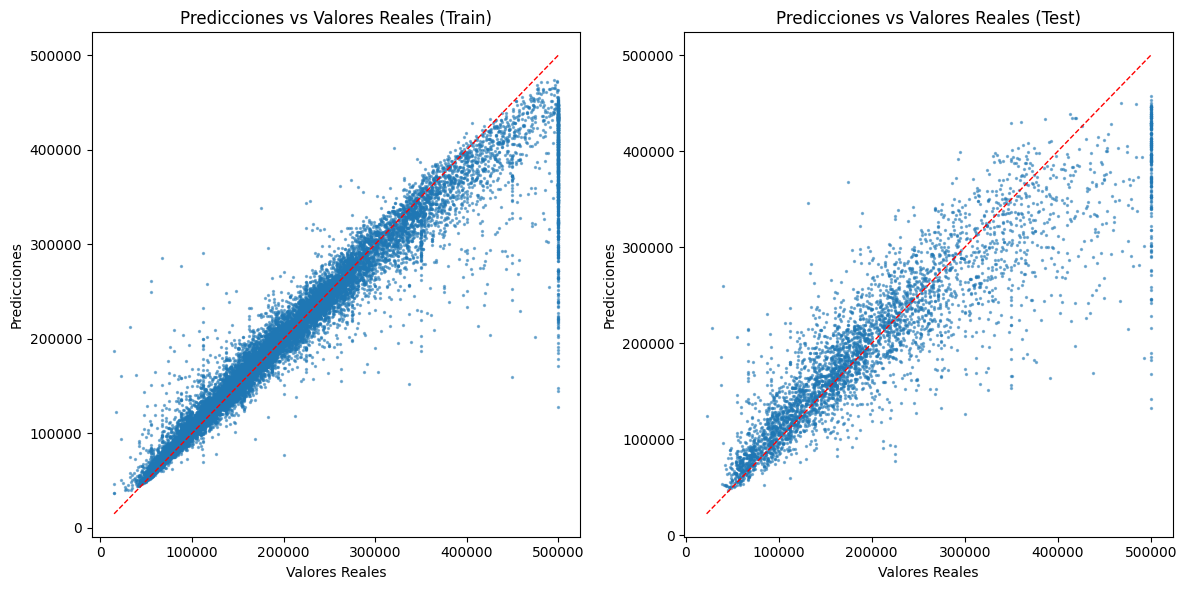

In [14]:
# Graficamos las predicciones vs los valores reales
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha=0.5, s=2)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Train)")
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5, s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Test)")
plt.tight_layout()
plt.show()

In [15]:
# Probamos modelo en casos con target menor al extremo superior de acuerdo con lo observado en la exploración (500,001 es el tope)

mask = (test["housing_median_age"] < 52) & (test["median_income"] < 15.0001) & (test[TARGET] < 500001)
test_subset = test[mask]

X_test_subset = test_subset.drop(columns=[TARGET])
y_test_subset = test_subset[TARGET]

test_subset_pred = best_model.predict(X_test_subset)
test_subset_rmse = np.sqrt(mean_squared_error(y_test_subset, test_subset_pred))

print(f"RMSE Test Subset (target < 500,001): {test_subset_rmse:.4f}")

RMSE Test Subset (target < 500,001): 43821.6911


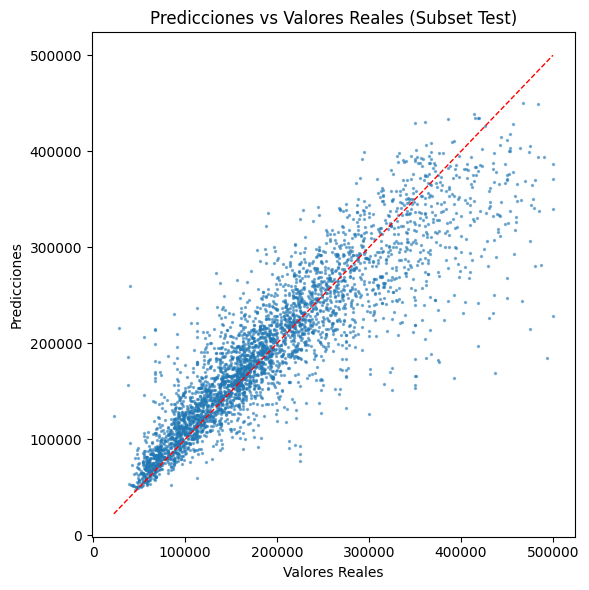

In [16]:
# Gráfico de predicciones vs valores reales para el subset
plt.figure(figsize=(6, 6))
plt.scatter(y_test_subset, test_subset_pred, alpha=0.5, s=2)
plt.plot([y_test_subset.min(), y_test_subset.max()], [y_test_subset.min(), y_test_subset.max()], 'r--', linewidth=1)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Subset Test)")
plt.tight_layout()
plt.show()

# 5. Conclusión y Benchmark



Concluímos que el mejor modelo es `RandomForestRegressor` con `n_estimators = 205` y `max_features = 6`. Verificamos que es preferible no eliminar los valores con límites superiores identificados en la exploración ya que esto nos puede sesgar cuando nos enfrentamos ante estos valores que es probable que se presenten cuando el modelo salga a producción.